In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import torch

In [2]:
import subprocess
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"USING DEVICE = {device}")
if(device == "cuda"):
    subprocess.run(["nvidia-smi"])
else:
    subprocess.run(["lscpu"])

USING DEVICE = cuda
Sat Jan 31 11:49:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.152                Driver Version: 573.24         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5070 ...    On  |   00000000:01:00.0 Off |                  N/A |
| N/A   46C    P8              6W /   80W |      47MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------------

In [3]:
from ultralytics import YOLO

model = YOLO("yolo11n-seg.pt")

In [5]:
#Train
train_results = model.train(
    data = "/home/oscar/Melanoma_Project/YOLOv11_dataset/data.yaml", # path to yaml file
    epochs = 100,
    imgsz = 512,
    batch = -1, #let it calculate the maximum batch
    patience = 5,
    dropout = 0.2,
    workers= 8,
    device = device,
    save = True,

    #mosaic = 0.0,
    #mixup = 0.0,
)

New https://pypi.org/project/ultralytics/8.4.9 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.5 🚀 Python-3.12.3 torch-2.11.0.dev20260113+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/oscar/Melanoma_Project/YOLOv11_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.2, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, 

In [ ]:
import os
import glob

base_path = "/home/oscar/Melanoma_Project/YOLOv11_dataset"
folders_to_check = ["train/labels","valid/labels", "test/labels"]

bad_files = []

print("Scanning Validation and Test folders...")

for folder in folders_to_check:
    search_path = os.path.join(base_path, folder, "*.txt")
    files = glob.glob(search_path)
    
    for f in files:
        with open(f, 'r') as file:
            lines = file.readlines()
        
        for line in lines:
            parts = line.strip().split()
            if not parts: continue
            
            #check: is it a box (Len < 6)
            if len(parts) < 6: 
                bad_files.append(f)
                break
            
            #check is it in the wrong class (rn we have only 2 classes)
            if int(parts[0]) > 1:
                bad_files.append(f)
                break

print(f"Found {len(bad_files)} bad files in Train/Validation/Test sets.")

# 2. Delete them
if bad_files:
    print("Deleting bad validation files...")
    for label_path in bad_files:
        try:
            # Delete Label
            os.remove(label_path)
            
            # Delete Images
            base = label_path.replace("labels", "images").rsplit('.', 1)[0]
            for ext in [".jpg", ".jpeg", ".png"]:
                if os.path.exists(base + ext):
                    os.remove(base + ext)
        except Exception as e:
            print(f"Error deleting {label_path}: {e}")
            
    print("Done. Now your validation step should pass.")
else:
    print("No bad files found in Valid/Test. (If so, the issue is elsewhere).")

Scanning Validation and Test folders...
Found 0 bad files in Train/Validation/Test sets.
No bad files found in Valid/Test. (If so, the issue is elsewhere).


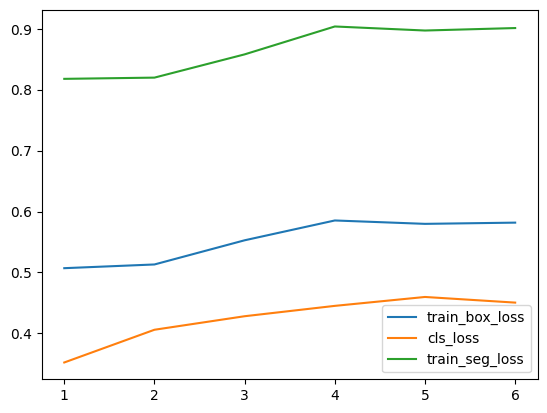

In [8]:
save_dir = train_results.save_dir # This gives you the path like 'runs/detect/train'
csv_path = f"{save_dir}/results.csv"

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

train_box_loss = df['train/box_loss']
val_cls_loss = df['val/cls_loss']
train_seg_loss = df['train/seg_loss']

plt.plot(df['epoch'], train_box_loss, label = 'train_box_loss')
plt.plot(df['epoch'], val_cls_loss, label = "cls_loss")
plt.plot(df['epoch'], train_seg_loss, label = 'train_seg_loss')
plt.legend()
plt.show()


Ultralytics 8.4.5 🚀 Python-3.12.3 torch-2.11.0.dev20260113+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,958 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 82.1±20.9 MB/s, size: 32.0 KB)
val: Scanning /home/oscar/Melanoma_Project/YOLOv11_dataset/valid/labels.cache... 569 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 569/569 108.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 9.1it/s 4.0s<0.1s
                   all        569        599      0.959      0.915      0.966      0.857      0.955      0.924      0.967      0.833
              Melanoma        198        210      0.945        0.9      0.951      0.842      0.943       0.91      0.953      0.814
                 Nevus        371        389      0.973       0.93      0.981      0.873      0.966      0.938 

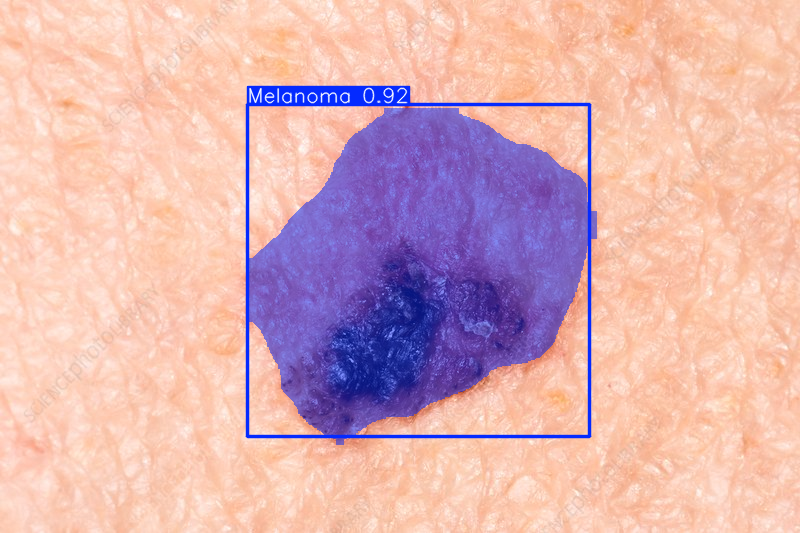

In [7]:
# Validate
metrics = model.val(
    data = "/home/oscar/Melanoma_Project/YOLOv11_dataset/data.yaml",
    save = False,
    plots = False,
)

results = model("/home/oscar/Melanoma_Project/images/Melanoma_66.jpg", save = False)
results[0].show()